# Logit Lens: Tracing Predictions Through Depth

**Survey Reference:** Section 8.1 — Logit Lens

The **Logit Lens** ([nostalgebraist, 2020](https://www.lesswrong.com/posts/AcKRB8wDpdaN6v6ru/interpreting-gpt-the-logit-lens)) reveals what a language model "believes" at each stage of processing. GPT's final prediction comes from projecting the last layer's hidden state into vocabulary space. The logit lens applies that **same projection to every intermediate layer**:

$$\text{LogitLens}(h_l) = \text{softmax}\big(\text{LayerNorm}(h_l) \cdot W_U\big)$$

where $h_l \in \mathbb{R}^{d}$ is the residual stream at layer $l$ and $W_U \in \mathbb{R}^{d \times |V|}$ is the unembedding matrix.

### Learning Objectives

1. Understand *why* the logit lens works (residual stream architecture)
2. Implement it from scratch with HuggingFace Transformers
3. Visualize and interpret layer-wise predictions
4. Analyze convergence with ranks and KL divergence
5. Know the limitations and motivation for the Tuned Lens
6. (Advanced) Use the logit lens to interpret SAE features

## 1. Setup

GPT-2 small: 124M params, 12 layers, 768-dim hidden states, 50,257 token vocabulary.

In [1]:
%pip install torch transformers matplotlib numpy sae-lens scipy --quiet


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_name = "openai-community/gpt2-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()
print(f"Loaded {model_name}: {model.config.n_layer} layers, d={model.config.n_embd}")

Using device: cuda
Loaded openai-community/gpt2-large: 36 layers, d=1280


## 2. What Is the Logit Lens?

GPT-2 processes text through a **residual stream** — each layer *adds* to a running hidden state:

$$h_{l+1} = h_l + \text{Attn}_l(h_l) + \text{MLP}_l(h_l)$$

The final prediction comes from projecting $h_L$ through a final LayerNorm and the unembedding matrix. Because each layer adds to (rather than replaces) the stream, intermediate states live in roughly the same vector space as the final output.

**The logit lens** applies that same final projection to every layer's output. Two properties make this work:
1. **Residual connections** keep all layers in approximately the same basis.
2. **Weight decay** during training encourages gradual, spread-out computation.

The result: we can watch the model's "guess" evolve from generic early-layer predictions toward the final answer.

In [3]:
def get_hidden_states(model, tokenizer, text):
    """Run a forward pass and return all layer hidden states + decoded tokens."""
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    tokens = [tokenizer.decode(t) for t in inputs.input_ids[0]]
    return outputs.hidden_states, tokens


def logit_lens(hidden_states, model):
    """Project every layer's hidden state to vocabulary space.

    Returns: tensor [n_layers+1, seq_len, vocab_size]
    """
    ln_f = model.transformer.ln_f
    unembed = model.lm_head.weight
    all_logits = []
    for h in hidden_states:
        all_logits.append((ln_f(h) @ unembed.T)[0])
    return torch.stack(all_logits)


text = "The Eiffel Tower is located in the city of"
hidden_states, tokens = get_hidden_states(model, tokenizer, text)
with torch.no_grad():
    all_logits = logit_lens(hidden_states, model)

# Layer-by-layer predictions at the last position
probs = F.softmax(all_logits[:, -1, :], dim=-1)
top_ids = all_logits[:, -1, :].argmax(dim=-1)

print(f'"{text}" \u2192 next token\n')
print(f'{"Layer":>8s}  {"Prediction":<14s}  {"Prob":>6s}')
print("-" * 32)
for i, tid in enumerate(top_ids):
    label = "embed" if i == 0 else f"layer {i-1}"
    print(f"{label:>8s}  {repr(tokenizer.decode(tid)):<14s}  {probs[i, tid].item():>6.3f}")

"The Eiffel Tower is located in the city of" → next token

   Layer  Prediction        Prob
--------------------------------
   embed  ' of'            1.000
 layer 0  ' the'           0.140
 layer 1  ' the'           0.043
 layer 2  ' the'           0.028
 layer 3  ' the'           0.022
 layer 4  ' the'           0.021
 layer 5  ' the'           0.020
 layer 6  ' the'           0.021
 layer 7  ' the'           0.017
 layer 8  ' West'          0.015
 layer 9  ' San'           0.030
layer 10  ' San'           0.054
layer 11  ' San'           0.041
layer 12  ' San'           0.044
layer 13  ' San'           0.063
layer 14  ' San'           0.092
layer 15  ' San'           0.117
layer 16  ' San'           0.130
layer 17  ' North'         0.088
layer 18  ' San'           0.115
layer 19  ' San'           0.110
layer 20  ' San'           0.122
layer 21  ' San'           0.078
layer 22  ' San'           0.082
layer 23  ' Amsterdam'     0.080
layer 24  ' Amsterdam'     0.145
layer 25  ' Paris

## 3. Visualizing the Logit Lens

The classic visualization is a **heatmap**: layers (Y) x token positions (X), each cell showing the top-1 predicted next token colored by probability. Blue outlines mark agreement with the final layer.

In [4]:
def plot_logit_lens(all_logits, tokens, tokenizer, title="Logit Lens"):
    """Classic logit lens heatmap."""
    n_layers, seq_len, _ = all_logits.shape
    probs = F.softmax(all_logits, dim=-1)
    max_probs, top_ids = probs.max(dim=-1)
    mp = max_probs.cpu().numpy()
    top_words = [[tokenizer.decode(top_ids[l, t].item()) for t in range(seq_len)]
                 for l in range(n_layers)]
    final_top = top_ids[-1]

    fig, ax = plt.subplots(figsize=(max(10, seq_len * 1.4), max(6, n_layers * 0.45)))
    im = ax.imshow(mp, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1, origin="lower")
    for l in range(n_layers):
        for t in range(seq_len):
            w = top_words[l][t]
            ax.text(t, l, w if len(w) <= 8 else w[:7] + "\u2026",
                    ha="center", va="center", fontsize=7,
                    color="white" if mp[l, t] > 0.55 else "black")
            if top_ids[l, t] == final_top[t]:
                ax.add_patch(plt.Rectangle((t-.5, l-.5), 1, 1,
                             lw=1.5, edgecolor="blue", facecolor="none"))
    ax.set_xticks(range(seq_len))
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Input Token")
    ax.set_yticks(range(n_layers))
    ax.set_yticklabels(["embed"] + [f"layer {i}" for i in range(n_layers-1)], fontsize=8)
    ax.set_ylabel("Layer")
    plt.colorbar(im, ax=ax, label="Top-1 Probability", shrink=0.8)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_prob_evolution(all_logits, tokens, tokenizer, position=-1, top_k=5):
    """Probability of the final layer's top-k tokens across all layers."""
    n_layers = all_logits.shape[0]
    p = F.softmax(all_logits[:, position, :], dim=-1)
    topk = p[-1].topk(top_k).indices.tolist()
    plt.figure(figsize=(9, 4))
    for tid in topk:
        plt.plot(range(n_layers), p[:, tid].cpu().numpy(),
                 marker="o", markersize=4, label=repr(tokenizer.decode(tid)))
    plt.xlabel("Layer"); plt.ylabel("Probability")
    plt.title(f'Probability evolution \u2014 "{" ".join(tokens)}"')
    plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

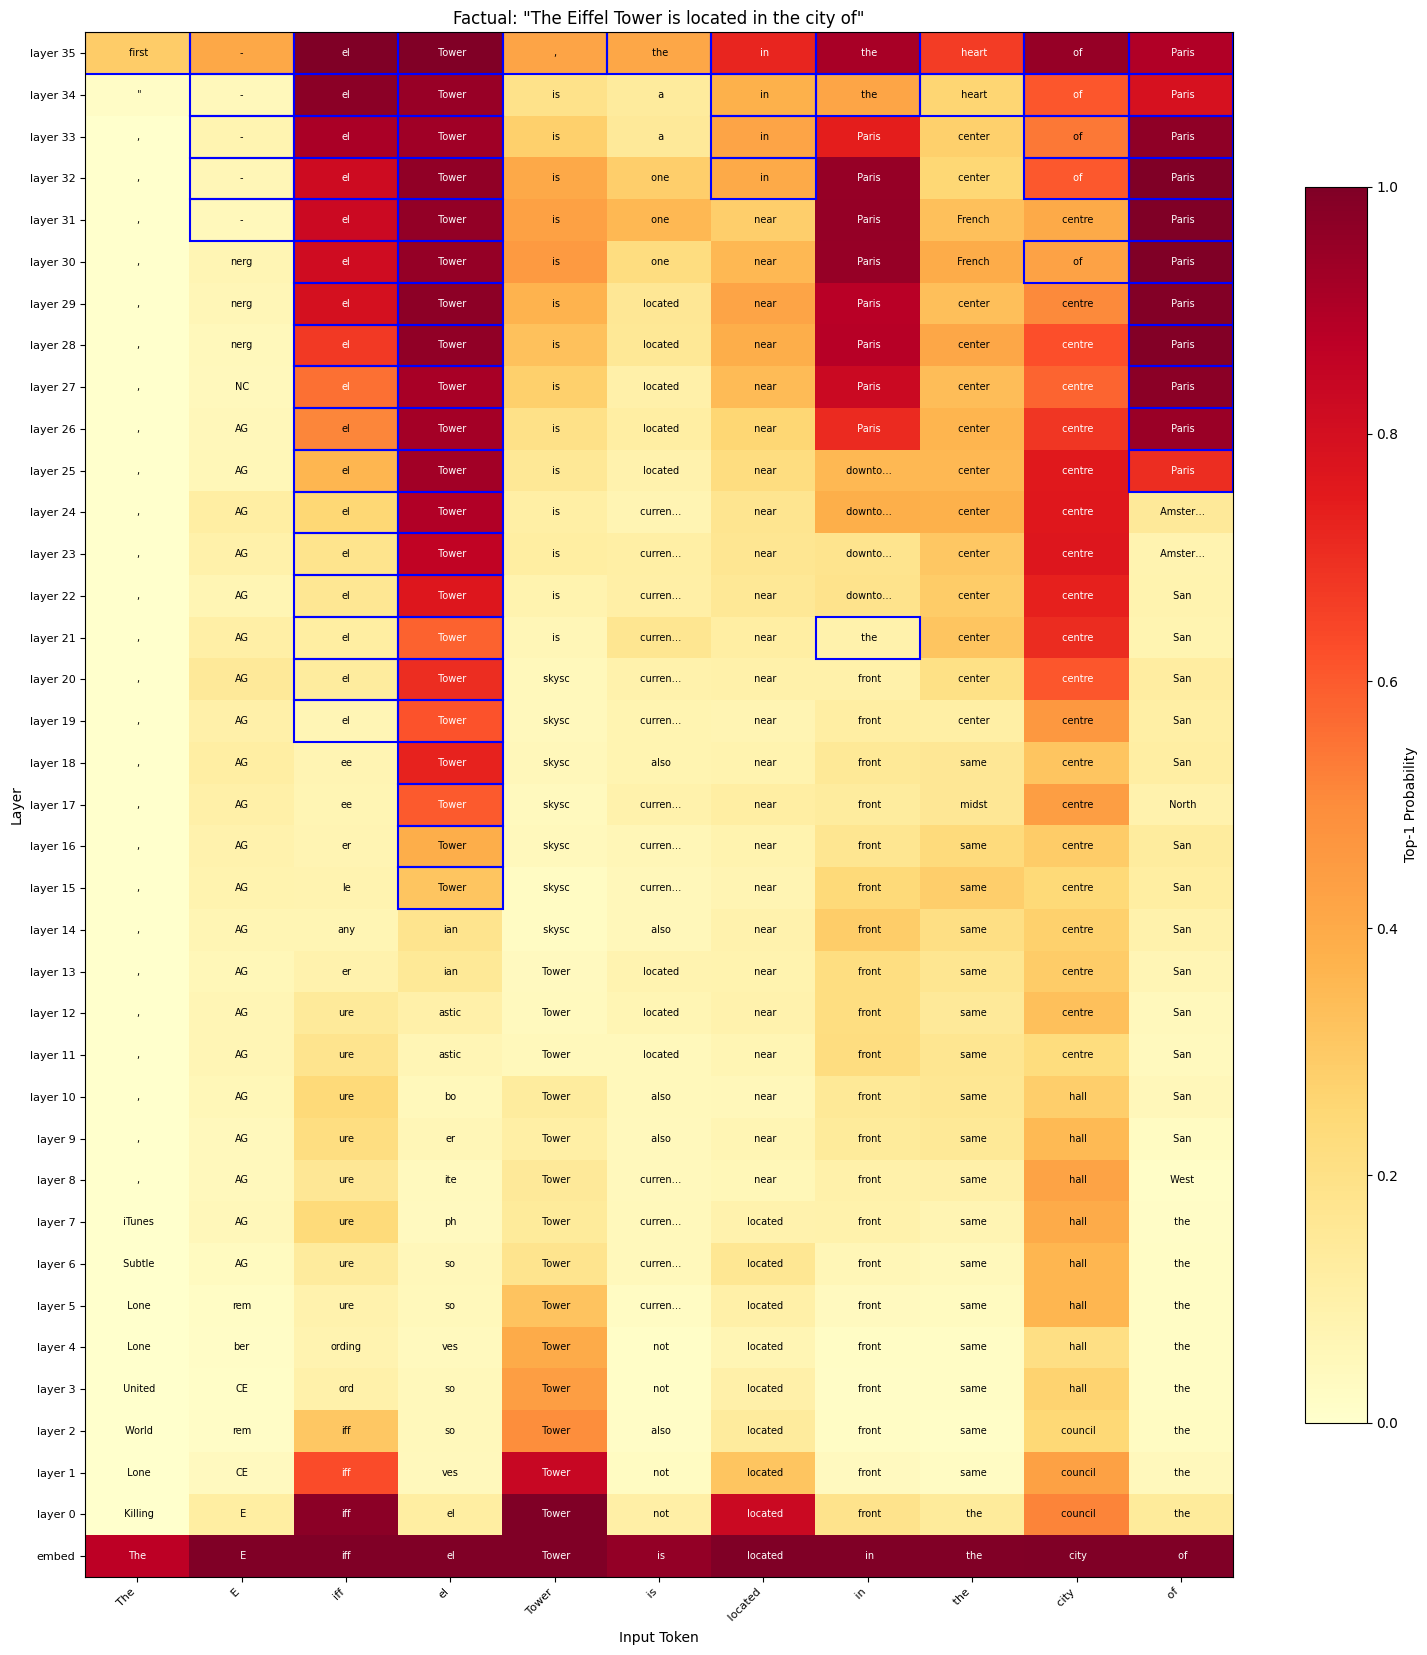

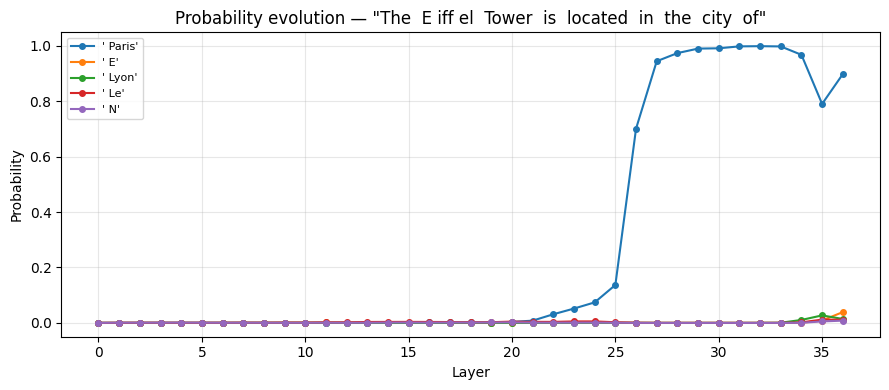

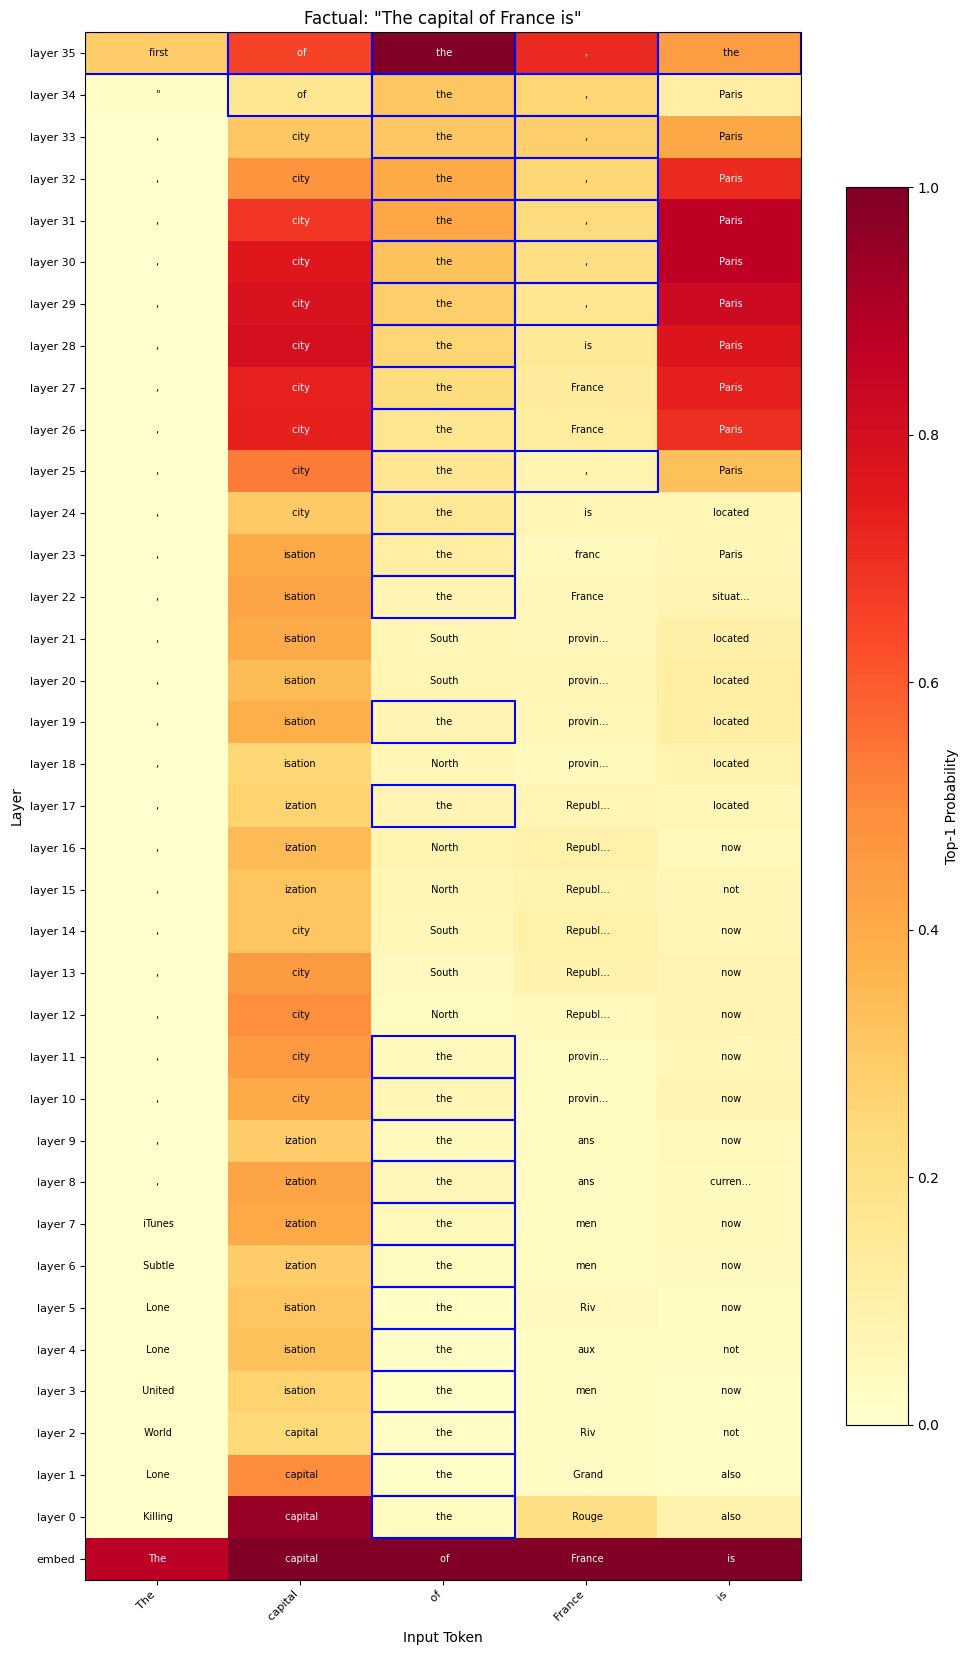

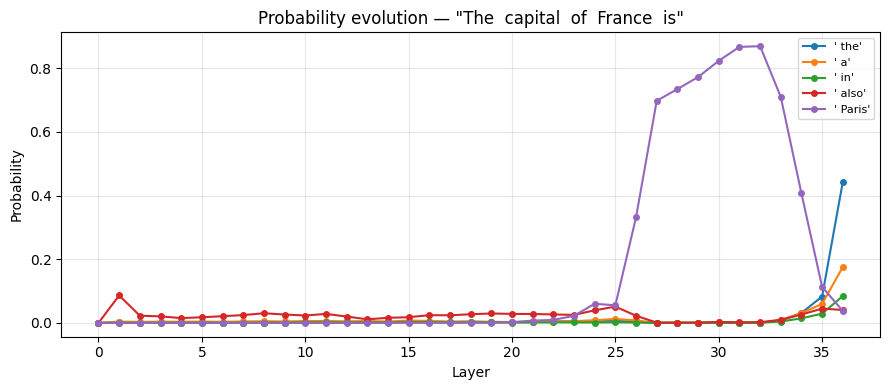

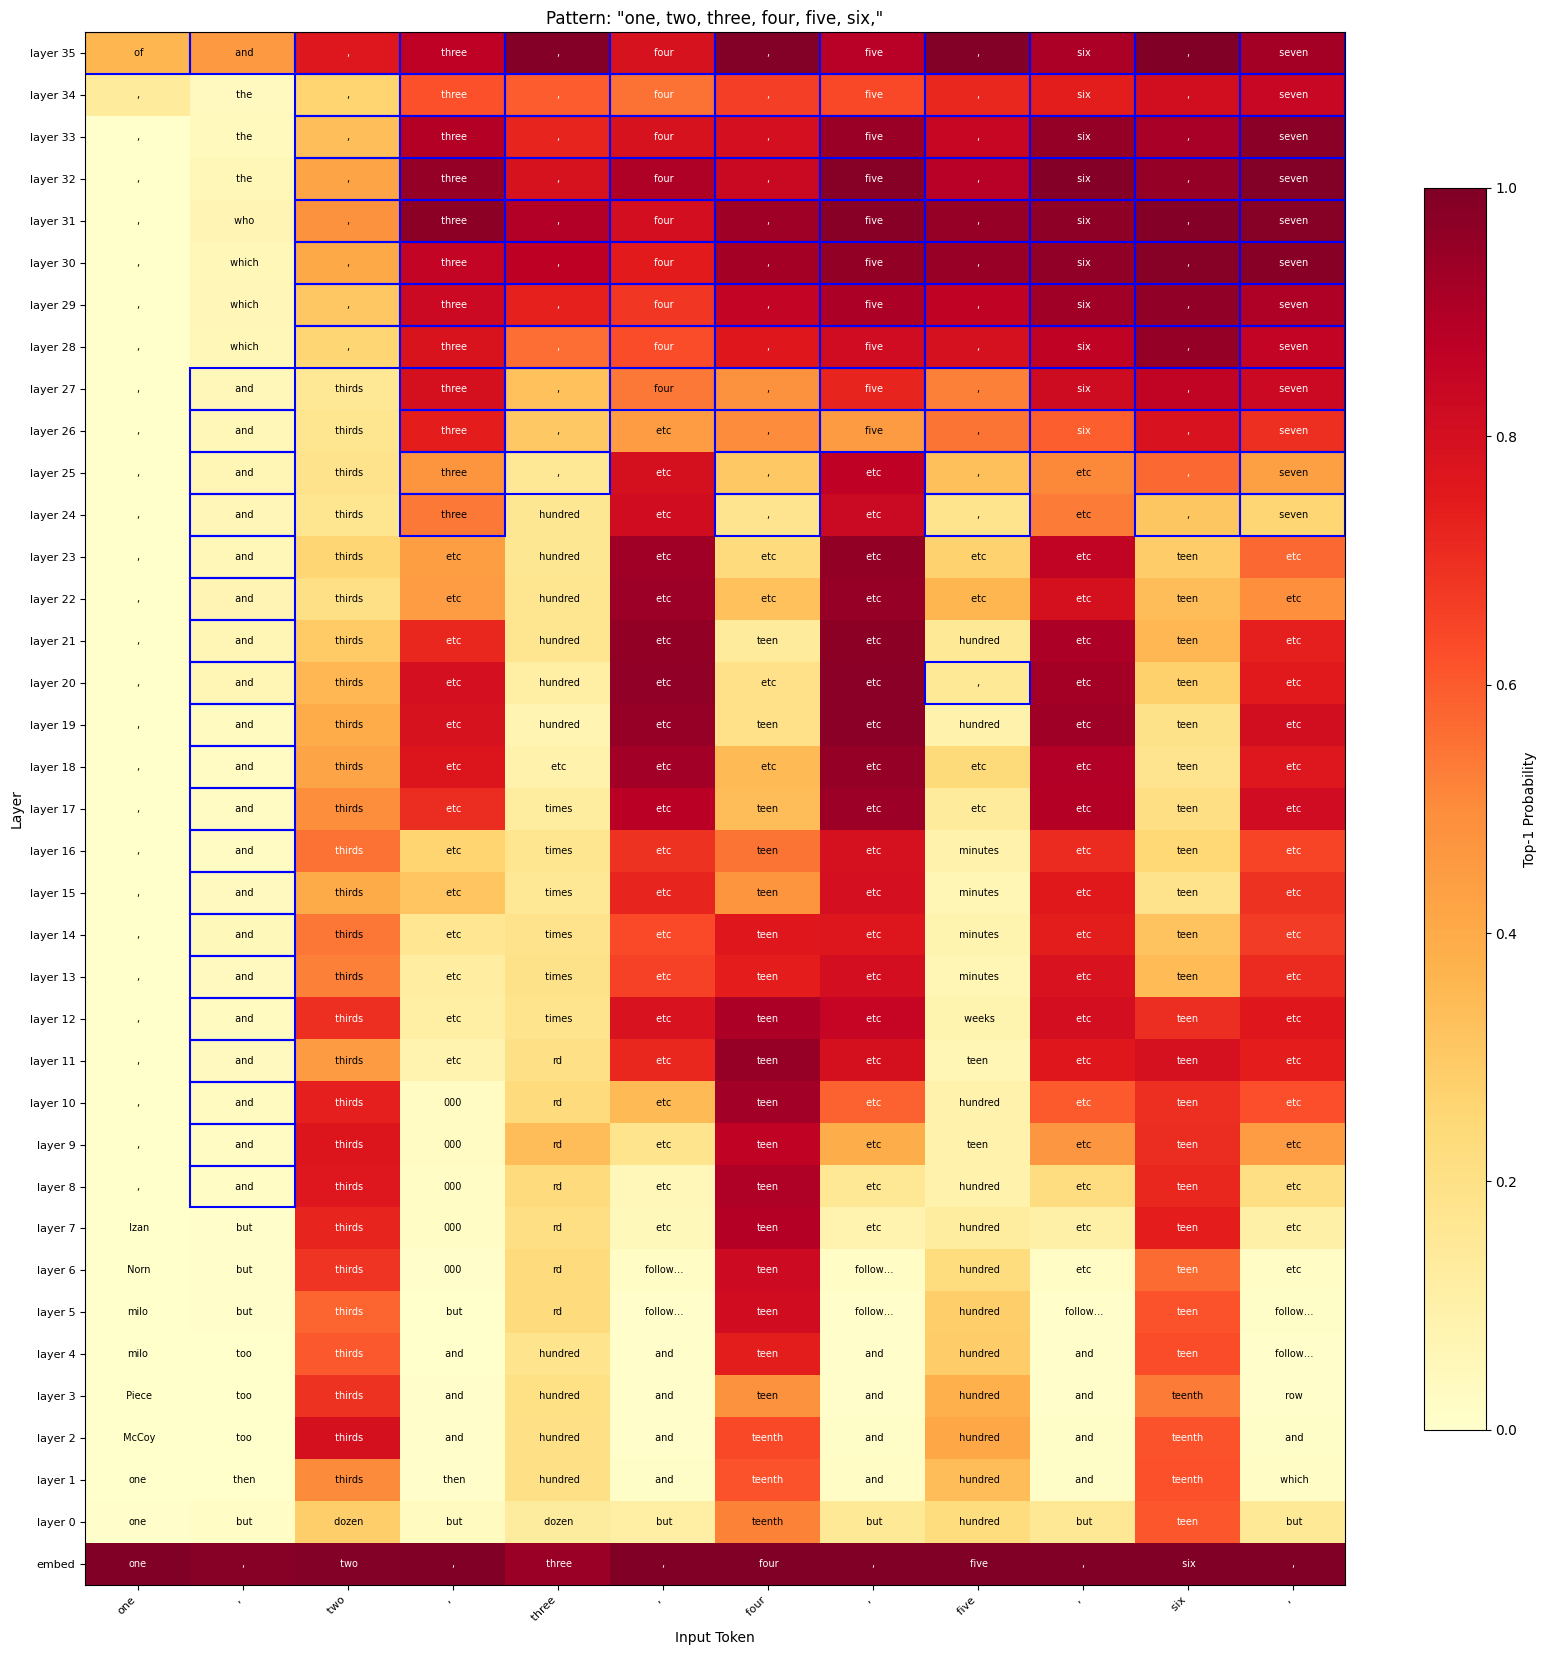

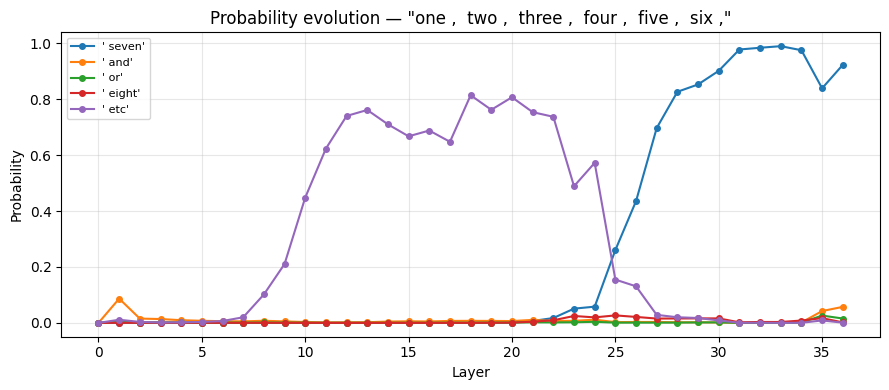

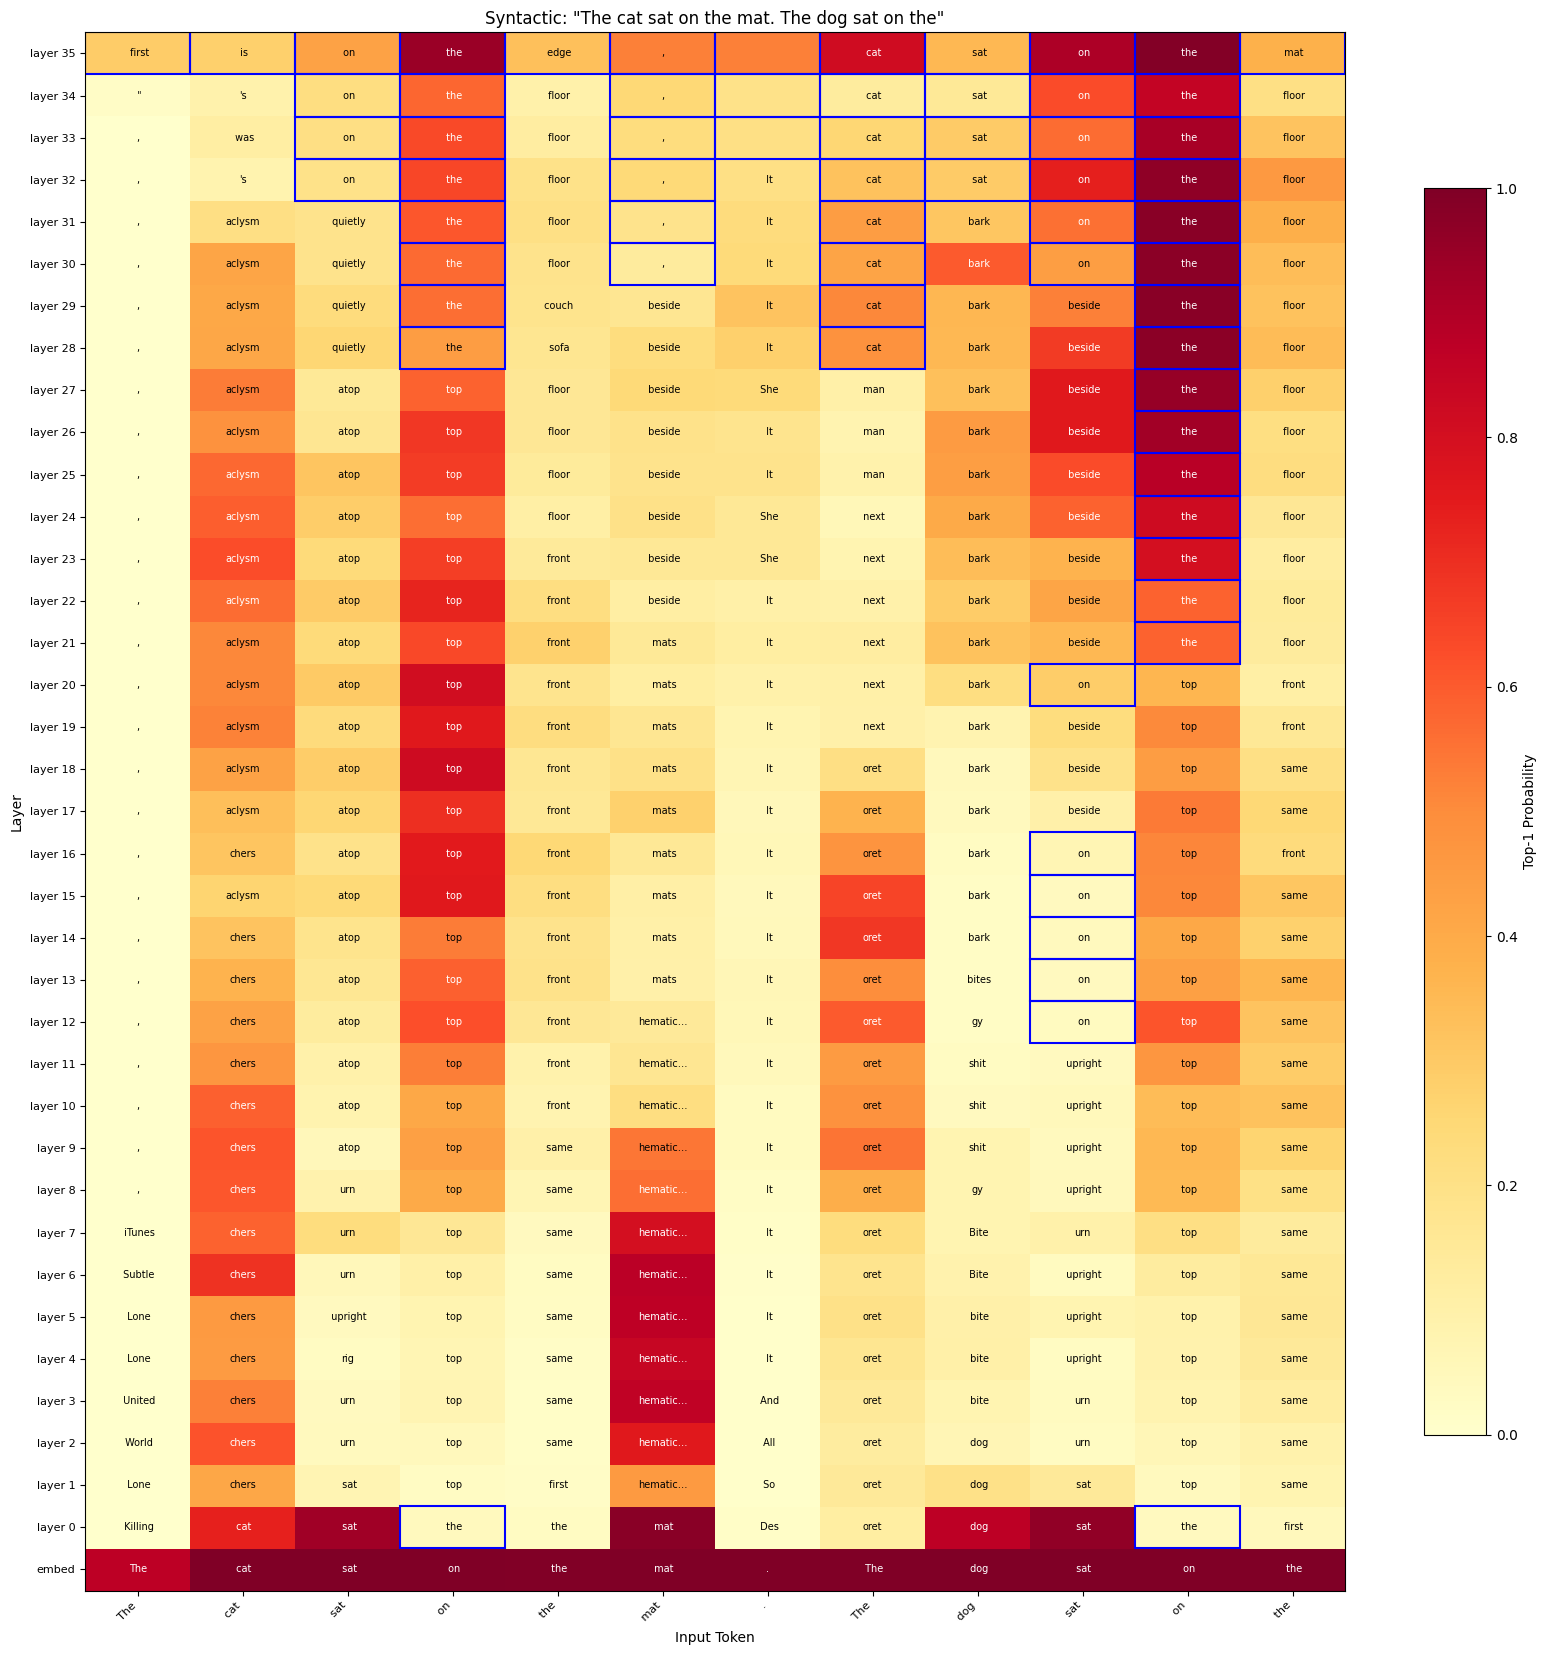

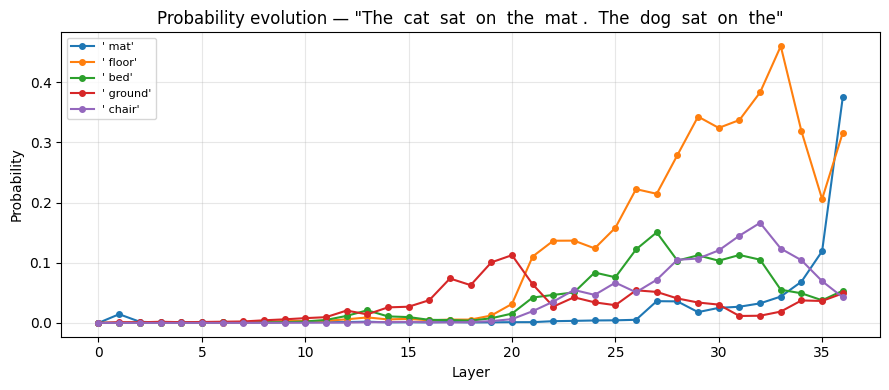

In [5]:
# Run on several prompts to see different convergence patterns
prompts = [
    ("Factual", "The Eiffel Tower is located in the city of"),
    ("Factual", "The capital of France is"),
    ("Pattern", "one, two, three, four, five, six,"),
    ("Syntactic", "The cat sat on the mat. The dog sat on the"),
]
for label, p in prompts:
    hs, toks = get_hidden_states(model, tokenizer, p)
    with torch.no_grad():
        lg = logit_lens(hs, model)
    plot_logit_lens(lg, toks, tokenizer, title=f'{label}: "{p}"')
    plot_prob_evolution(lg, toks, tokenizer)

**How to read these plots:**

- **Early layers** (bottom) show generic, high-frequency tokens — shallow guesses before much processing has happened. For the Eiffel Tower prompt, early layers return tokens like "the" or "a."
- **Middle layers** narrow down: geographic associations like "France" begin surfacing around layers 4-5. By layer 6-7, "Paris" first appears as the top prediction, initially at low probability.
- **Late layers** (top) lock in "Paris" with rapidly increasing confidence, reaching 90%+ at the final layer.
- **Blue outlines** spread downward from the top as layers agree on the final prediction.
- **Probability curves** show the competition between candidates — you can see the winning token's probability rise and competitors fall.

These patterns also serve as a debugging tool: when the model gets something wrong, the heatmap shows *where* the wrong prediction forms and whether the correct answer ever appeared in earlier layers.

## 4. Rank Analysis

Top-1 probability is narrow — the correct answer might rank 5th out of 50K tokens at layer 3, a huge reduction in uncertainty even if probability is low. **Rank analysis** shows how quickly the model narrows its search space.

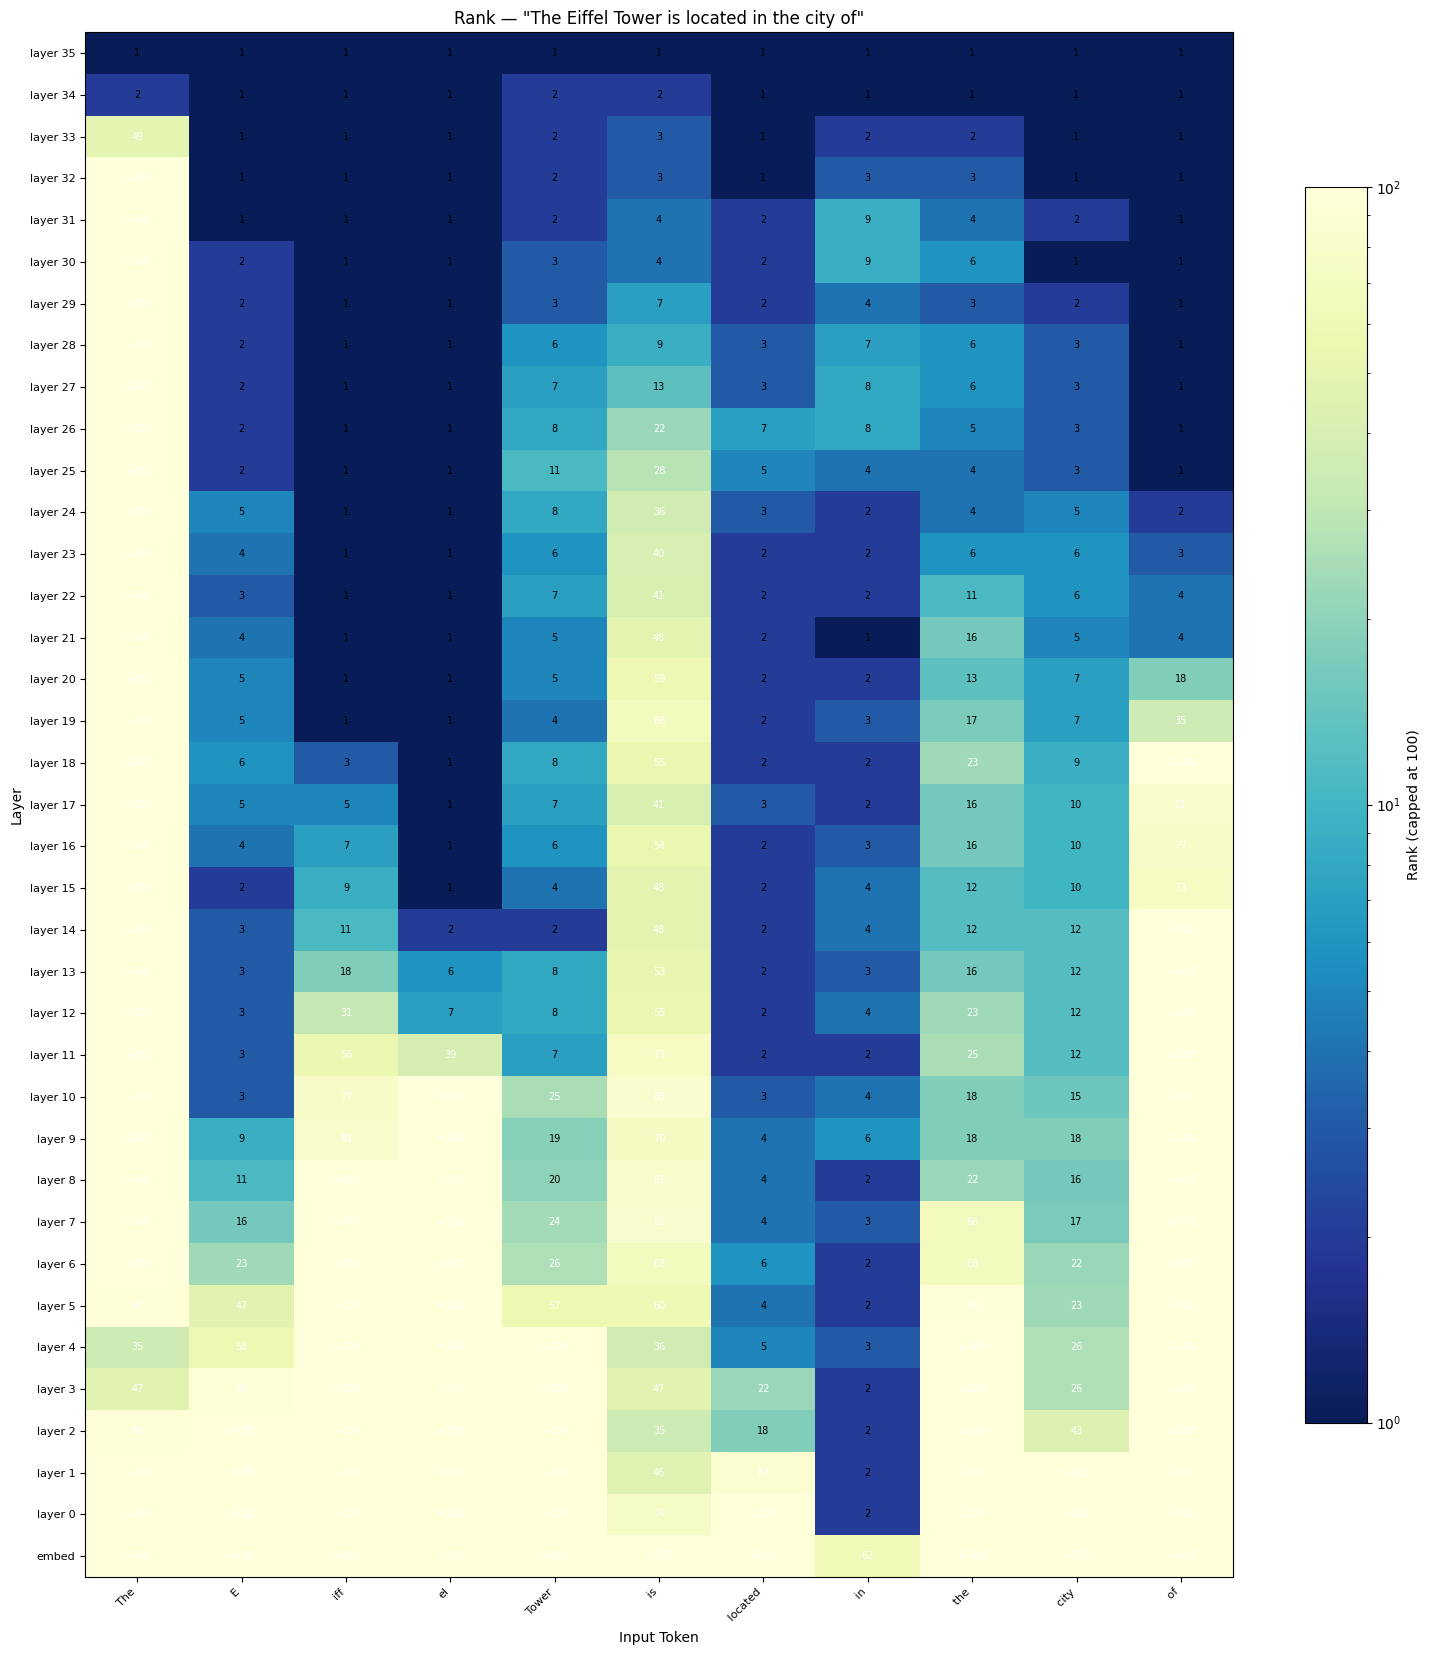

In [6]:
def compute_ranks(all_logits):
    """Rank of the final layer's top prediction at each (layer, position)."""
    n_layers, seq_len, _ = all_logits.shape
    final_top = all_logits[-1].argmax(dim=-1)
    ranks = np.zeros((n_layers, seq_len), dtype=int)
    for l in range(n_layers):
        sorted_idx = all_logits[l].argsort(dim=-1, descending=True)
        for t in range(seq_len):
            ranks[l, t] = (sorted_idx[t] == final_top[t]).nonzero(as_tuple=True)[0].item() + 1
    return ranks


def plot_rank_heatmap(all_logits, tokens, title="Rank of Final Prediction", max_rank=100):
    ranks = compute_ranks(all_logits)
    n_layers, seq_len = ranks.shape
    fig, ax = plt.subplots(figsize=(max(10, seq_len*1.4), max(6, n_layers*0.45)))
    im = ax.imshow(np.clip(ranks, 1, max_rank), aspect="auto", cmap="YlGnBu_r",
                   norm=mcolors.LogNorm(vmin=1, vmax=max_rank), origin="lower")
    for l in range(n_layers):
        for t in range(seq_len):
            r = ranks[l, t]
            ax.text(t, l, str(r) if r <= max_rank else f">{max_rank}",
                    ha="center", va="center", fontsize=7,
                    color="white" if r > 20 else "black")
    ax.set_xticks(range(seq_len))
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Input Token")
    ax.set_yticks(range(n_layers))
    ax.set_yticklabels(["embed"] + [f"layer {i}" for i in range(n_layers-1)], fontsize=8)
    ax.set_ylabel("Layer")
    plt.colorbar(im, ax=ax, label=f"Rank (capped at {max_rank})", shrink=0.8)
    ax.set_title(title); plt.tight_layout(); plt.show()

plot_rank_heatmap(all_logits, tokens, title='Rank \u2014 "The Eiffel Tower is located in the city of"')

## 5. KL Divergence — Convergence Across Layers

Probability and rank focus on single tokens. **KL divergence** compares the *entire distribution* at each layer to the final layer, giving a holistic convergence measure:

$$\text{KL}(P_{\text{final}} \| P_l) = \sum_v P_{\text{final}}(v) \log \frac{P_{\text{final}}(v)}{P_l(v)}$$

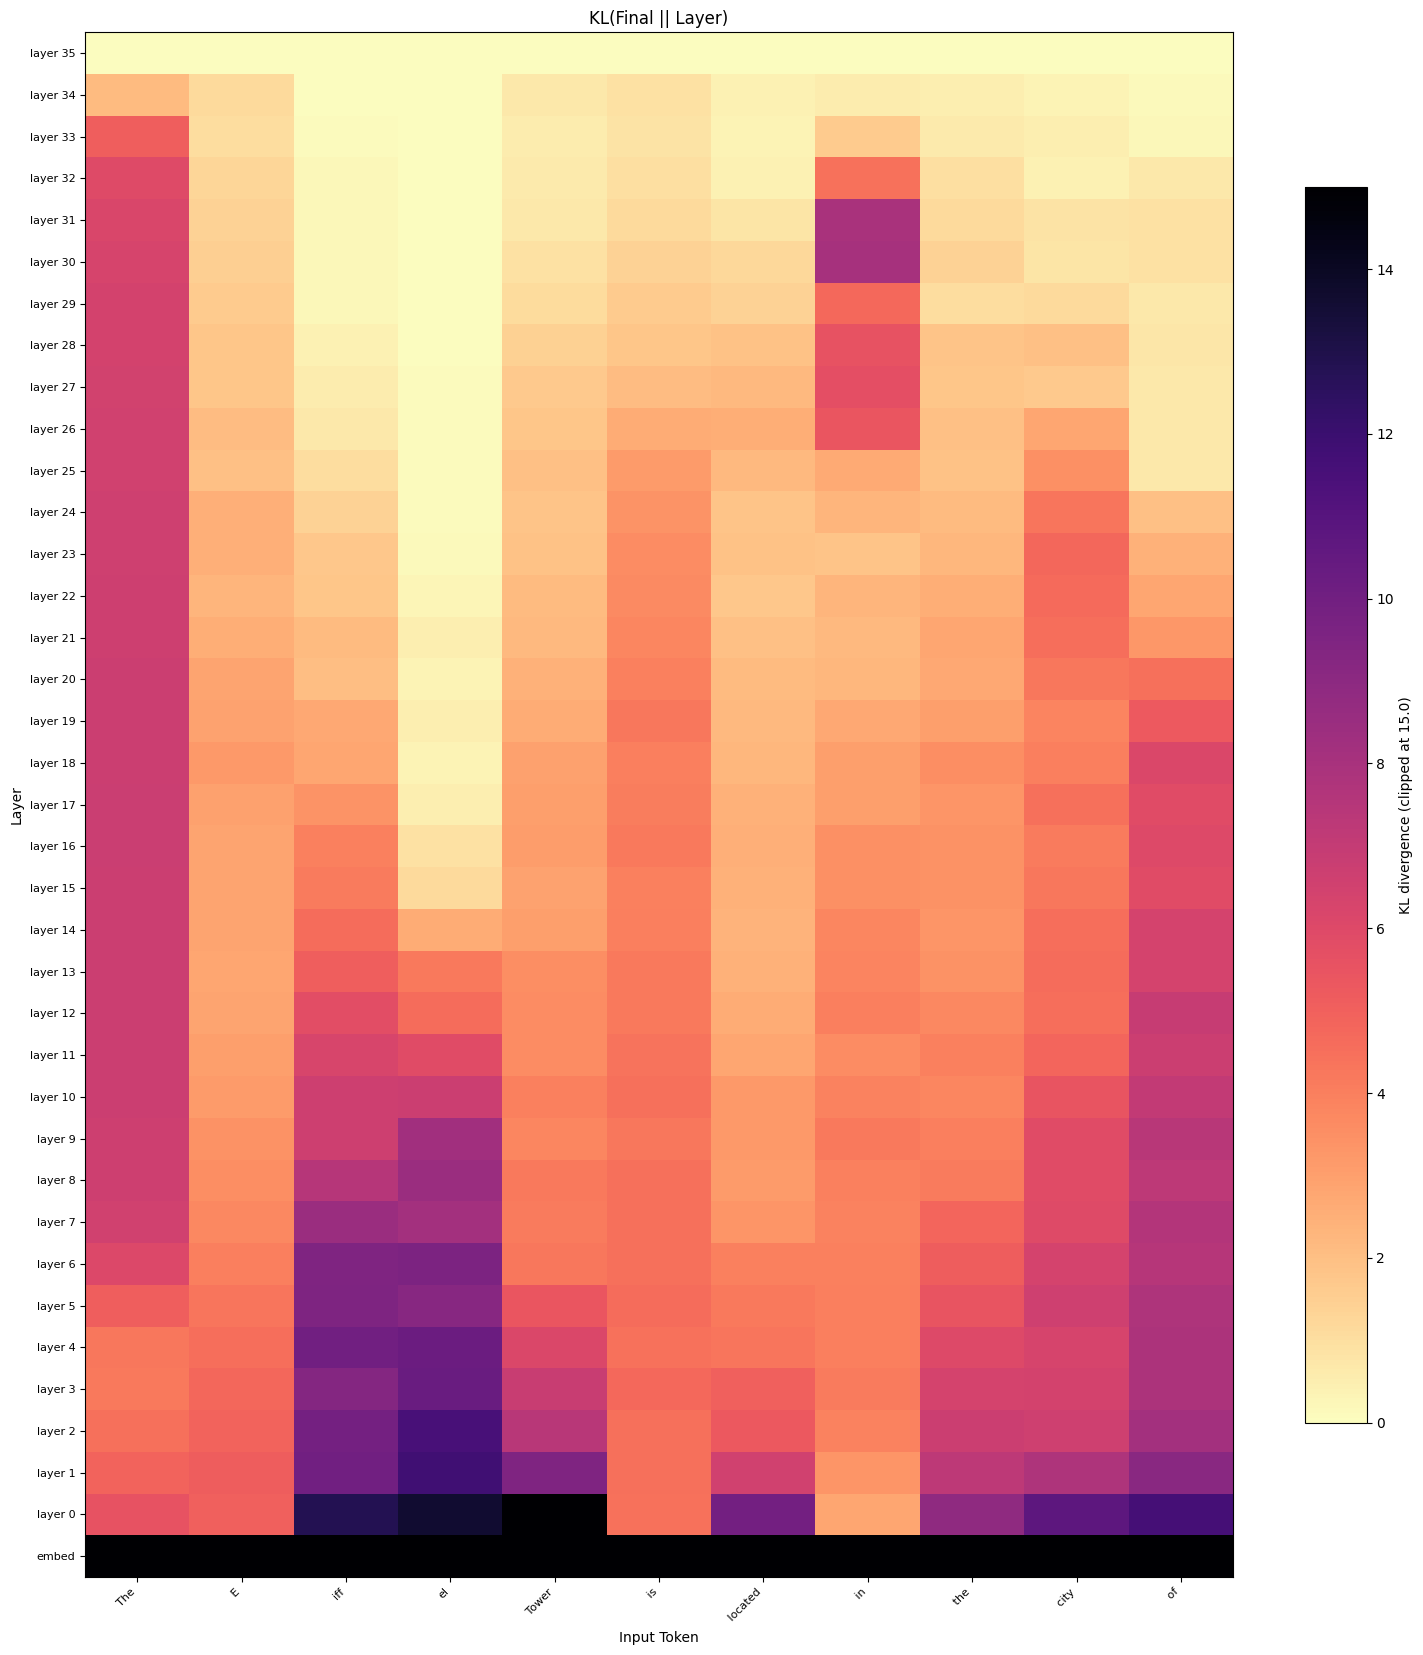

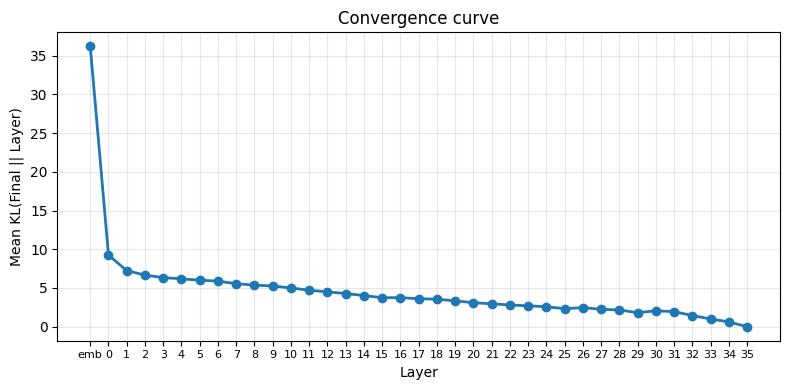

Embed→Layer 0 drop: 36.2 → 9.2 (74% reduction)


In [7]:
def compute_kl_from_final(all_logits):
    """KL(P_final || P_layer) for every (layer, position)."""
    with torch.no_grad():
        log_p = F.log_softmax(all_logits.detach(), dim=-1)
        p = F.softmax(all_logits.detach(), dim=-1)
        final_p, final_lp = p[-1].unsqueeze(0), log_p[-1].unsqueeze(0)
        return (final_p * (final_lp - log_p)).sum(dim=-1).cpu().numpy()


def plot_kl_heatmap(all_logits, tokens, title="KL(Final || Layer)", vmax=15.0):
    kl = compute_kl_from_final(all_logits)
    n_layers, seq_len = kl.shape
    fig, ax = plt.subplots(figsize=(max(10, seq_len*1.4), max(6, n_layers*0.45)))
    im = ax.imshow(np.clip(kl, 0, vmax), aspect="auto", cmap="magma_r",
                   vmin=0, vmax=vmax, origin="lower")
    ax.set_xticks(range(seq_len))
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Input Token")
    ax.set_yticks(range(n_layers))
    ax.set_yticklabels(["embed"] + [f"layer {i}" for i in range(n_layers-1)], fontsize=8)
    ax.set_ylabel("Layer")
    plt.colorbar(im, ax=ax, label=f"KL divergence (clipped at {vmax})", shrink=0.8)
    ax.set_title(title); plt.tight_layout(); plt.show()

plot_kl_heatmap(all_logits, tokens)

# Convergence curve
kl = compute_kl_from_final(all_logits)
mean_kl = kl.mean(axis=1)
plt.figure(figsize=(8, 4))
plt.plot(range(len(mean_kl)), mean_kl, marker="o", lw=2)
plt.xticks(range(len(mean_kl)), ["emb"] + [str(i) for i in range(len(mean_kl)-1)], fontsize=8)
plt.xlabel("Layer"); plt.ylabel("Mean KL(Final || Layer)")
plt.title("Convergence curve"); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Embed\u2192Layer 0 drop: {mean_kl[0]:.1f} \u2192 {mean_kl[1]:.1f} ({100*(1-mean_kl[1]/mean_kl[0]):.0f}% reduction)")

**Key insight — "thinking in predictive space":** After just one layer, KL drops dramatically — the model immediately converts inputs into something resembling the final output, then smoothly refines. It does not "keep inputs around" — it starts predicting from layer 1.

## 6. Limitations and Applications

### Limitations

1. **Representation drift:** Early layers may use a different effective basis than the unembedding expects, making their decoded predictions noisy. The logit lens works well for GPT-2 but is systematically biased and fails on models like GPT-Neo, BLOOM, and OPT.
2. **LayerNorm mismatch:** The final LayerNorm was trained for the last layer — applying it to early representations may distort them.
3. **Lossy projection:** The residual stream ($d=768$) contains information that projecting to vocab space cannot capture.
4. **Observation ≠ Causation:** The logit lens shows what the model *would predict* if processing stopped — it does **not** prove that the computation at any layer is *necessary* for the final output. Establishing causation requires intervention methods like activation patching.

These motivate the **Tuned Lens** ([Belrose et al., 2023](https://arxiv.org/abs/2303.08112)), which learns a per-layer affine transform $\text{TunedLens}(h_\ell) = (A_\ell h_\ell + b_\ell) \cdot W_U$ to correct for basis changes. The key design choice: translators minimize KL divergence from the *final layer's output* (not ground truth), so they faithfully report what the model believes, not what is true.

### Applications

Despite its limitations, the logit lens observation — that predictions refine progressively across layers — has inspired practical applications:

- **DoLa** ([Li et al., 2023](https://arxiv.org/abs/2309.03883)): Contrasts logit distributions between early and late layers at inference time to amplify factual knowledge, reducing hallucinations without fine-tuning.
- **Multilingual processing** ([Wendler et al., 2024](https://arxiv.org/abs/2310.10554)): Vocabulary projections revealed that multilingual LLMs process non-English inputs through an internal "concept space" that skews toward English in middle layers, then translates back for output.
- **Multi-hop reasoning** ([Yang et al., 2024](https://arxiv.org/abs/2404.18765)): Logit lens + activation patching showed that models perform latent multi-hop reasoning — for "The mother of the president of the US is ___," intermediate layers first resolve "president of the US" to a specific entity before retrieving the mother.

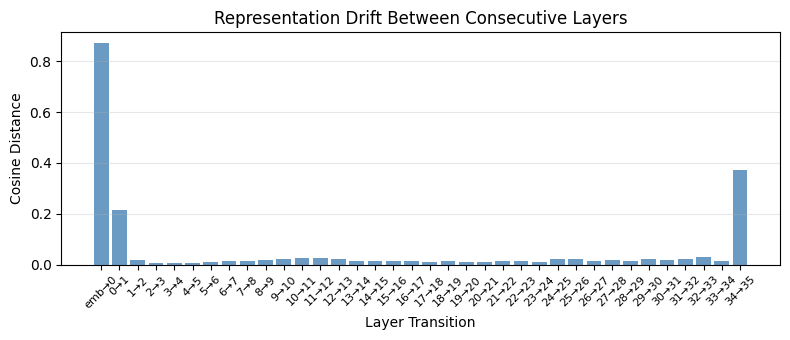

In [16]:
# Measure representation drift: cosine distance between consecutive layers
drifts = []
for i in range(1, len(hidden_states)):
    h_prev = hidden_states[i-1][:, -1, :]
    h_curr = hidden_states[i][:, -1, :]
    drifts.append(1.0 - F.cosine_similarity(h_prev, h_curr, dim=-1).item())

plt.figure(figsize=(8, 3.5))
plt.bar(range(1, len(drifts)+1), drifts, color="steelblue", alpha=0.8)
plt.xlabel("Layer Transition"); plt.ylabel("Cosine Distance")
plt.title("Representation Drift Between Consecutive Layers")
plt.xticks(range(1, len(drifts)+1),
           ["emb\u21920"] + [f"{i}\u2192{i+1}" for i in range(len(drifts)-1)], fontsize=8, rotation=45)
plt.grid(True, alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

## 7. Advanced: Extended Logit Lens

The standard logit lens applies LayerNorm + unembedding directly to each layer's hidden state. But early layers may use a *different effective basis* than what the unembedding expects (representation drift).

[Belrose et al. (2023)](https://arxiv.org/abs/2303.08112) introduce the **Extended Logit Lens** (Eq. 4 in the Tuned Lens paper), which passes each intermediate hidden state through the **final transformer block** before unembedding:

$$\text{LogitLens}^{\text{ext}}(h_\ell) = \text{LayerNorm}\big[h_\ell + F_L(h_\ell)\big] \cdot W_U$$

where $F_L$ is the residual function (attention + MLP, without the skip connection) of the last block. In HuggingFace GPT-2, `GPT2Block.forward` already includes the residual connection internally, so `final_block(h)[0]` directly computes $h + F_L(h)$.

The intuition: the final block acts as a "translator" that maps any representation closer to the basis the unembedding expects. The paper notes that this extension is *"only partially successful"* for models like GPT-Neo, but it works well for GPT-2. The **KL divergence** between the extended logit lens and the final layer is typically 3-8x lower than the standard version — though this improvement is hard to see from top-1 token labels alone, since the full *distribution* is much closer even when the argmax differs.

In [9]:
def extended_logit_lens(hidden_states, model):
    """Extended logit lens: pass each layer's output through the final block before unembedding."""
    ln_f = model.transformer.ln_f
    unembed = model.lm_head.weight
    final_block = model.transformer.h[-1]

    all_logits = []
    for h in hidden_states:
        with torch.no_grad():
            # GPT2Block already includes the residual connection internally,
            # so final_block(h)[0] = h + Attn(h) + MLP(h). No need to add h again.
            extended_h = final_block(h)[0]
            all_logits.append((ln_f(extended_h) @ unembed.T)[0])
    return torch.stack(all_logits)

# Compute both standard and extended logit lens for comparison
text = "The Eiffel Tower is located in the city of"
hidden_states_ext, tokens_ext = get_hidden_states(model, tokenizer, text)
standard_logits = logit_lens(hidden_states_ext, model)
extended_logits = extended_logit_lens(hidden_states_ext, model)

print(f"Prompt: '{text}'")
print(f"Final prediction: '{tokenizer.decode(standard_logits[-1, -1].argmax().item())}'")

Prompt: 'The Eiffel Tower is located in the city of'
Final prediction: ' Paris'


/home/hunarbatra/Interpretability_Survey_Safety/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hunarbatra/Interpretability_Survey_Safety/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8 ) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hunarbatra/Interpretability_Survey_Safety/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 16 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


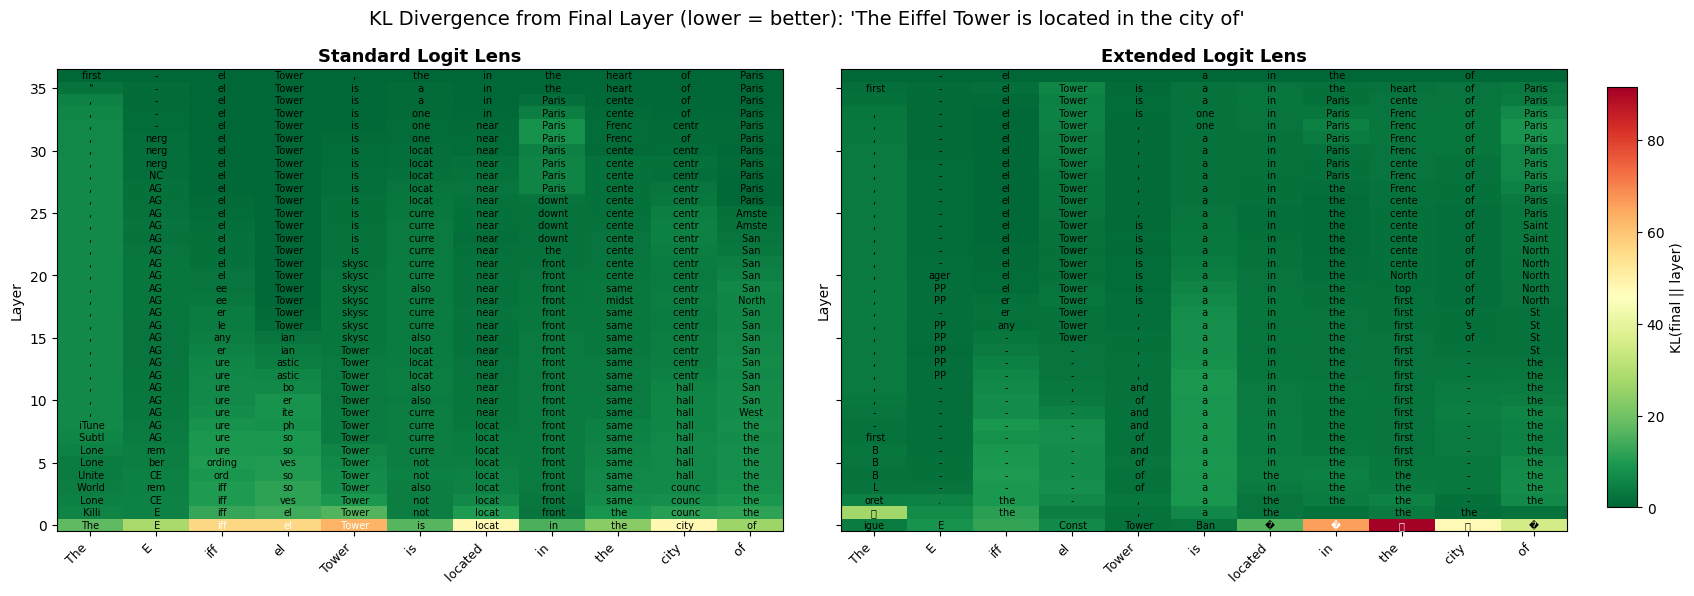

In [10]:
# Side-by-side KL divergence heatmap: standard vs extended logit lens
std_kl = compute_kl_from_final(standard_logits)
ext_kl = compute_kl_from_final(extended_logits)
vmax = max(std_kl.max(), ext_kl.max())

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

for ax, kl_vals, logits, title in [
    (axes[0], std_kl, standard_logits, "Standard Logit Lens"),
    (axes[1], ext_kl, extended_logits, "Extended Logit Lens"),
]:
    n_layers, n_tokens = logits.shape[0], logits.shape[1]
    top_tokens = logits.argmax(dim=-1)
    labels = [[tokenizer.decode(top_tokens[l, t].item()) for t in range(n_tokens)]
              for l in range(n_layers)]

    im = ax.imshow(kl_vals, aspect="auto", origin="lower", cmap="RdYlGn_r", vmin=0, vmax=vmax)
    for l in range(n_layers):
        for t in range(n_tokens):
            txt = labels[l][t][:6]
            ax.text(t, l, txt, ha="center", va="center", fontsize=7,
                    color="white" if kl_vals[l, t] > vmax * 0.6 else "black")
    ax.set_xticks(range(n_tokens))
    ax.set_xticklabels(tokens_ext, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Layer")
    ax.set_title(title, fontsize=13, fontweight="bold")

plt.suptitle(f"KL Divergence from Final Layer (lower = better): '{text}'", fontsize=14)
fig.subplots_adjust(right=0.88, wspace=0.08)
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="KL(final || layer)")
plt.show()

/home/hunarbatra/Interpretability_Survey_Safety/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hunarbatra/Interpretability_Survey_Safety/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8 ) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hunarbatra/Interpretability_Survey_Safety/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 16 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


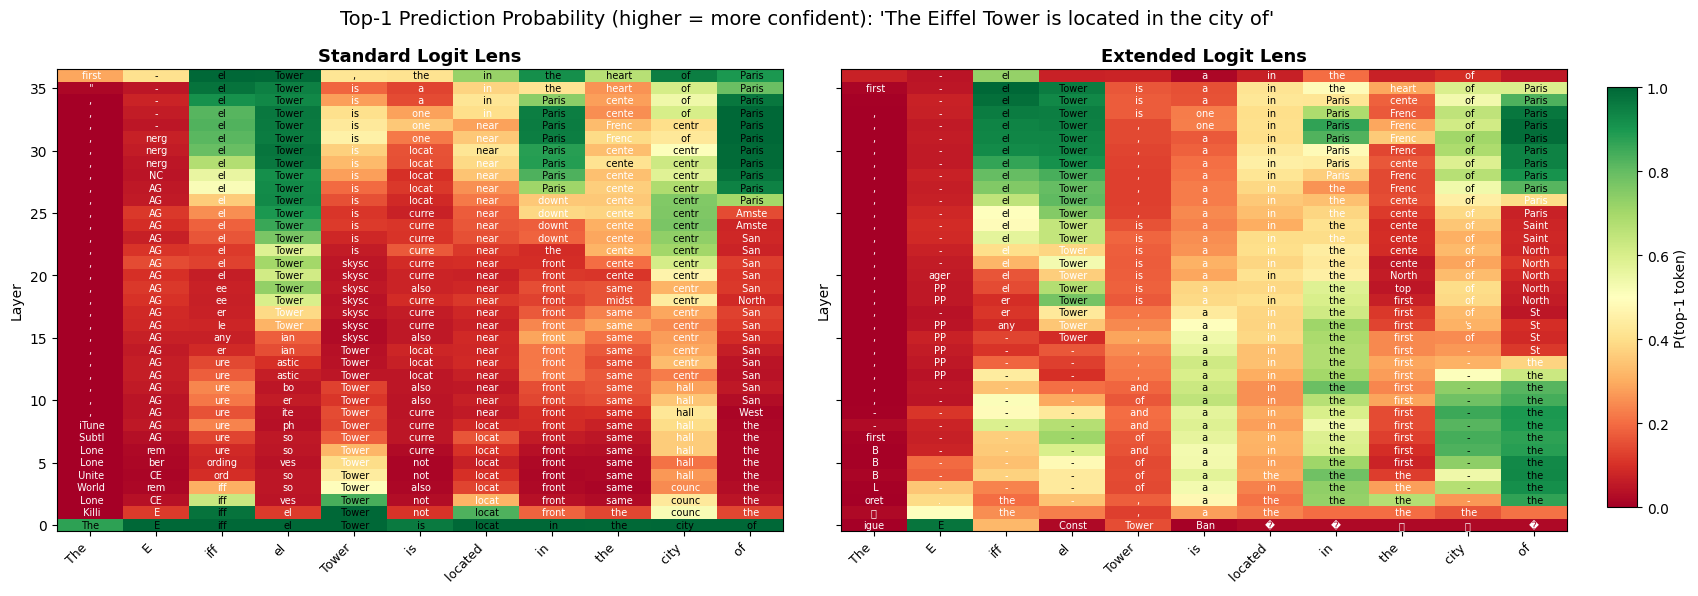

In [11]:
# Side-by-side Top-1 Prediction Probability heatmap: standard vs extended logit lens
def compute_top1_prob(all_logits):
    """Compute top-1 prediction probability for every (layer, position)."""
    with torch.no_grad():
        probs = F.softmax(all_logits.detach(), dim=-1)
        top1_probs = probs.max(dim=-1).values
        return top1_probs.cpu().numpy()

std_top1 = compute_top1_prob(standard_logits)
ext_top1 = compute_top1_prob(extended_logits)

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

for ax, top1_vals, logits, title in [
    (axes[0], std_top1, standard_logits, "Standard Logit Lens"),
    (axes[1], ext_top1, extended_logits, "Extended Logit Lens"),
]:
    n_layers, n_tokens = logits.shape[0], logits.shape[1]
    top_tokens = logits.argmax(dim=-1)
    labels = [[tokenizer.decode(top_tokens[l, t].item()) for t in range(n_tokens)]
              for l in range(n_layers)]

    im = ax.imshow(top1_vals, aspect="auto", origin="lower", cmap="RdYlGn", vmin=0, vmax=1)
    for l in range(n_layers):
        for t in range(n_tokens):
            txt = labels[l][t][:6]
            ax.text(t, l, txt, ha="center", va="center", fontsize=7,
                    color="white" if top1_vals[l, t] < 0.4 else "black")
    ax.set_xticks(range(n_tokens))
    ax.set_xticklabels(tokens_ext, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Layer")
    ax.set_title(title, fontsize=13, fontweight="bold")

plt.suptitle(f"Top-1 Prediction Probability (higher = more confident): '{text}'", fontsize=14)
fig.subplots_adjust(right=0.88, wspace=0.08)
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="P(top-1 token)")
plt.show()

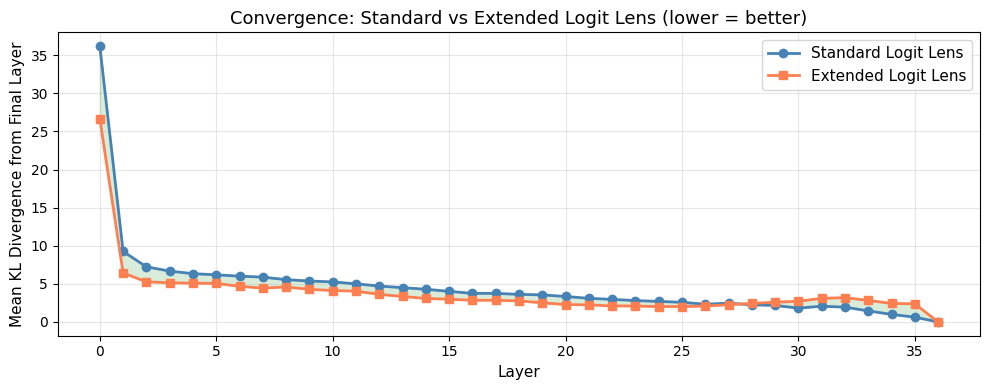

Average KL reduction across layers 0-35: -2%

  Layer 0: KL reduced by 26% (36.20 -> 26.67)
  Layer 1: KL reduced by 30% (9.25 -> 6.43)
  Layer 2: KL reduced by 27% (7.24 -> 5.26)
  Layer 3: KL reduced by 23% (6.67 -> 5.14)
  Layer 4: KL reduced by 20% (6.34 -> 5.09)
  Layer 5: KL reduced by 18% (6.18 -> 5.06)
  Layer 6: KL reduced by 22% (6.01 -> 4.68)
  Layer 7: KL reduced by 25% (5.88 -> 4.44)
  Layer 8: KL reduced by 17% (5.55 -> 4.59)
  Layer 9: KL reduced by 20% (5.37 -> 4.27)
  Layer 10: KL reduced by 21% (5.25 -> 4.13)
  Layer 11: KL reduced by 19% (5.00 -> 4.03)
  Layer 12: KL reduced by 23% (4.71 -> 3.63)
  Layer 13: KL reduced by 26% (4.50 -> 3.34)
  Layer 14: KL reduced by 28% (4.29 -> 3.08)
  Layer 15: KL reduced by 26% (4.02 -> 2.98)
  Layer 16: KL reduced by 24% (3.75 -> 2.84)
  Layer 17: KL reduced by 24% (3.75 -> 2.85)
  Layer 18: KL reduced by 24% (3.62 -> 2.76)
  Layer 19: KL reduced by 29% (3.55 -> 2.51)
  Layer 20: KL reduced by 32% (3.34 -> 2.28)
  Layer 21: KL re

In [12]:
# Quantitative comparison: mean KL divergence from the final layer
mean_std_kl = std_kl.mean(axis=1)
mean_ext_kl = ext_kl.mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
layers = range(len(mean_std_kl))
ax.plot(layers, mean_std_kl, "o-", label="Standard Logit Lens", color="steelblue", linewidth=2)
ax.plot(layers, mean_ext_kl, "s-", label="Extended Logit Lens", color="coral", linewidth=2)
ax.fill_between(layers, mean_ext_kl, mean_std_kl, alpha=0.15, color="green")
ax.set_xlabel("Layer", fontsize=11)
ax.set_ylabel("Mean KL Divergence from Final Layer", fontsize=11)
ax.set_title("Convergence: Standard vs Extended Logit Lens (lower = better)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

improvement = (mean_std_kl - mean_ext_kl) / (mean_std_kl + 1e-8) * 100
avg_imp = improvement[:-1].mean()
print(f"Average KL reduction across layers 0-{len(improvement)-2}: {avg_imp:.0f}%\n")
for l in range(len(improvement)):
    if improvement[l] > 5:
        print(f"  Layer {l}: KL reduced by {improvement[l]:.0f}% ({mean_std_kl[l]:.2f} -> {mean_ext_kl[l]:.2f})")

The extended logit lens typically shows the biggest improvement in **early-to-middle layers** where representation drift is worst. By layer ~8-9 (of 12), the standard and extended versions converge since the representations are already close to the final basis.

This technique was used in the LLaMA logit lens analysis by Batra (2023) and is conceptually related to the **Tuned Lens** (Belrose et al., 2023) — both address representation drift, but the extended logit lens uses the model's own final block rather than learned affine transforms.

## 8. Advanced: Logit Lens on SAE Features

The logit lens idea extends beyond hidden states to individual **Sparse Autoencoder (SAE) features**. Each SAE feature has a decoder direction $d_i \in \mathbb{R}^{d}$. Projecting it through the unembedding gives a **logit weight distribution** over the full vocabulary:

$$\text{logit\_weight}_i = d_i \cdot W_U$$

Positive entries are tokens the feature **promotes**; negative entries are tokens it **suppresses**. This provides a complementary view to activation-based analysis: activations tell you *when* a feature fires, while the logit weight distribution tells you *what tokens it steers toward*.

Reference: [Bloom & Lin (2024) - Understanding SAE Features with the Logit Lens](https://www.alignmentforum.org/posts/qykrYY6rXXM7EEs8Q/understanding-sae-features-with-the-logit-lens)

In [ ]:
from sae_lens import SAE

# Load GPT-2 small model for SAE analysis (SAE is trained on GPT-2 small)
gpt2_small = AutoModelForCausalLM.from_pretrained("openai-community/gpt2").to(device)
gpt2_small.eval()
print(f"Loaded GPT-2 small: {gpt2_small.config.n_layer} layers, d_model={gpt2_small.config.n_embd}")

# Load pre-trained SAE for residual stream at layer 8
sae = SAE.from_pretrained(
    release="gpt2-small-res-jb",
    sae_id="blocks.8.hook_resid_pre",
)
sae = sae.to(device)
print(f"SAE: {sae.cfg.d_sae} features, d_model={sae.cfg.d_in}")

# Project SAE decoder directions through unembedding (logit lens on features)
W_dec = sae.W_dec.detach()               # [n_features, d_model]
W_U = gpt2_small.lm_head.weight.detach() # [vocab_size, d_model]
logit_weights = W_dec @ W_U.T            # [n_features, vocab_size]
print(f"Logit weight matrix: {logit_weights.shape}")

Loaded GPT-2 small: 12 layers, d_model=768
SAE: 24576 features, d_model=768
Logit weight matrix: torch.Size([24576, 50257])


/home/hunarbatra/Interpretability_Survey_Safety/.venv/lib/python3.11/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


In [ ]:
def inspect_feature(feature_idx, logit_weights, tokenizer, top_k=10):
    """Show which tokens a feature promotes and suppresses via logit lens."""
    weights = logit_weights[feature_idx]
    top_vals, top_idx = weights.topk(top_k)
    bot_vals, bot_idx = weights.topk(top_k, largest=False)
    
    print(f"\n{'='*60}")
    print(f"Feature {feature_idx}")
    print(f"{'='*60}")
    print(f"  Top PROMOTED tokens (feature pushes model toward these):")
    for v, i in zip(top_vals, top_idx):
        print(f"    {repr(tokenizer.decode(i.item())):<20s} weight: {v.item():+.4f}")
    print(f"\n  Top SUPPRESSED tokens (feature pushes model away from these):")
    for v, i in zip(bot_vals, bot_idx):
        print(f"    {repr(tokenizer.decode(i.item())):<20s} weight: {v.item():+.4f}")

# Inspect a few example features
# Feature indices known to be interpretable in gpt2-small-res-jb layer 8
print("Example 1: Inspecting feature 0")
inspect_feature(0, logit_weights, tokenizer)

print("\nExample 2: Inspecting feature 100")
inspect_feature(100, logit_weights, tokenizer)

print("\nExample 3: Inspecting feature 500")
inspect_feature(500, logit_weights, tokenizer)

Example 1: Inspecting feature 0

Feature 0
  Top PROMOTED tokens (feature pushes model toward these):
    'etheless'           weight: +0.8543
    'ciating'            weight: +0.8094
    'nown'               weight: +0.7981
    'inventoryQuantity'  weight: +0.7885
    'thirds'             weight: +0.7872
    'ItemThumbnailImage' weight: +0.7871
    'tions'              weight: +0.7807
    'doms'               weight: +0.7793
    ' thirds'            weight: +0.7485
    'taboola'            weight: +0.7309

  Top SUPPRESSED tokens (feature pushes model away from these):
    ' --'                weight: -0.3066
    'normal'             weight: -0.2628
    ' ('                 weight: -0.2613
    ' normal'            weight: -0.2493
    ':'                  weight: -0.2405
    '\n\n'               weight: -0.2397
    ' the'               weight: -0.2327
    ' Ant'               weight: -0.2322
    ' Kun'               weight: -0.2287
    ' jo'                weight: -0.2286

Example 2: I

**Interpreting the logit weight distributions:**

The logit lens on SAE features reveals what each feature "wants" the model to predict:

- **Promoted tokens** (positive weights): When this feature activates, it pushes the model's output distribution toward these tokens.
- **Suppressed tokens** (negative weights): The feature pushes probability mass *away* from these tokens.

This technique is valuable because:
1. It's **cheap** — just a matrix multiply, no forward passes needed
2. It's **complementary** to activation analysis — activations show *when* features fire, logit weights show *what effect* they have
3. It can reveal **semantic structure** — features often promote coherent token sets (e.g., all digits, all past-tense verbs, all country names)

## Key Takeaways

1. **The logit lens** projects intermediate hidden states to vocabulary space via LayerNorm + unembedding, revealing what the model "believes" at each layer.
2. **Predictions form gradually** — generic early guesses narrow to the final answer across layers. For "The Eiffel Tower is located in the city of," geographic associations appear by layer 4, and "Paris" emerges by layer 6-7.
3. **Rank analysis** shows the model "knows" the answer long before it becomes the top prediction.
4. **KL divergence** reveals immediate input-to-prediction conversion — the model "thinks in predictive space."
5. **Observation ≠ causation** — the logit lens shows what *exists* at each layer, not what *matters*. Activation patching is needed for causal claims.
6. **Limitations** (representation drift, LayerNorm mismatch) motivate improved methods like the Tuned Lens.
7. **The extended logit lens** passes hidden states through the final transformer block before unembedding, reducing early-layer noise from representation drift.
8. **SAE feature projection** extends the logit lens to interpret individual learned features — statistics like skewness and kurtosis reveal distinct feature classes (prediction, suppression, partition).

## References

- **nostalgebraist (2020).** [Interpreting GPT: The Logit Lens](https://www.lesswrong.com/posts/AcKRB8wDpdaN6v6ru/interpreting-gpt-the-logit-lens). AI Alignment Forum.
- **Belrose et al. (2023).** [Eliciting Latent Predictions from Transformers with the Tuned Lens](https://arxiv.org/abs/2303.08112). NeurIPS 2023.
- **Bloom & Lin (2024).** [Understanding SAE Features with the Logit Lens](https://www.alignmentforum.org/posts/qykrYY6rXXM7EEs8Q/understanding-sae-features-with-the-logit-lens). AI Alignment Forum.
- **Gurnee et al. (2024).** [Universal Neurons in GPT2 Language Models](https://arxiv.org/abs/2401.12181). arXiv.
- **Li et al. (2023).** [DoLa: Decoding by Contrasting Layers](https://arxiv.org/abs/2309.03883). ICLR 2024.
- **Wendler et al. (2024).** [Do Llamas Work in English?](https://arxiv.org/abs/2310.10554). NAACL 2024.
- **Yang et al. (2024).** [Large Language Models Can Perform Latent Multi-Hop Reasoning](https://arxiv.org/abs/2404.18765). ACL 2024.

---

**Next:** [02_tuned_lens.ipynb](02_tuned_lens.ipynb) — per-layer affine transforms for better intermediate decoding